In [12]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [13]:
df = pd.read_csv('standardscaler.csv')

In [14]:
df.head()

,Feature1,Feature2,Feature3,Target
0,7,506815,78179.054805,147107.322662
1,4,293822,70538.588873,127684.231772
2,8,77218,44636.920014,87982.249559
3,5,588518,86421.631346,166046.587018
4,7,771044,55814.069145,101011.603738


In [15]:
x = df.drop(columns = 'Target')
y =  df.Target

In [16]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

<Axes: >

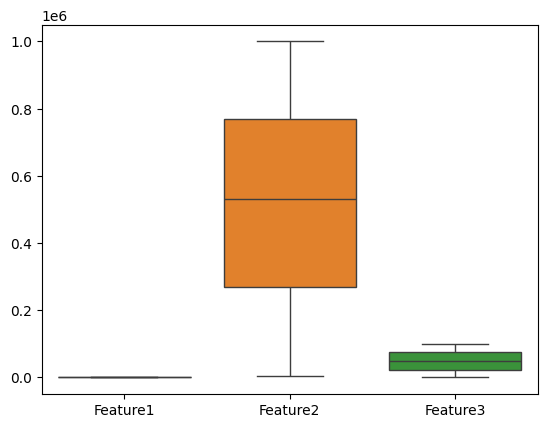

In [18]:
sns.boxplot(x)

In [17]:
scaling =  RobustScaler()
# updated_xtrain = scaling.fit_transform(xtrain['Feature1'])

'''
ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. 
Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

'''
updated_xtrain = scaling.fit_transform(xtrain)
updated_xtest =  scaling.transform(xtest)

In [19]:
model =  LinearRegression()
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
#model evaluation
#train score
''' 
score()
model.score(xtrain,ytrain) #for train data
model.score(xtest,ytest) #for test data

#1) finds y_pred value with the help of xtrain,xtest
#2) uses r2_score()
'''
model.score(updated_xtrain,ytrain)

0.990280886960456

In [21]:
model.score(updated_xtest,ytest)


0.9902822563064013